# *EDA - Step 1*

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

In [145]:
A = pd.read_csv("Bike-Sales-Dashboard.csv")
A

,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike
0,12496,Married,Female,"$40,000",1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,Middle Age,No
1,24107,Married,Male,"$30,000",3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,Middle Age,No
2,14177,Married,Male,"$80,000",5,Partial College,Professional,No,2,2-5 Miles,Europe,60,Old,No
3,24381,Single,Male,"$70,000",0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Middle Age,Yes
4,25597,Single,Male,"$30,000",0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Middle Age,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,"$60,000",2,High School,Professional,Yes,2,2-5 Miles,North America,54,Middle Age,Yes
996,28672,Single,Male,"$70,000",4,Graduate Degree,Professional,Yes,0,2-5 Miles,North America,35,Middle Age,Yes
997,11809,Married,Male,"$60,000",2,Bachelors,Skilled Manual,Yes,0,0-1 Miles,North America,38,Middle Age,Yes
998,19664,Single,Male,"$100,000",3,Bachelors,Management,No,3,1-2 Miles,North America,38,Middle Age,No


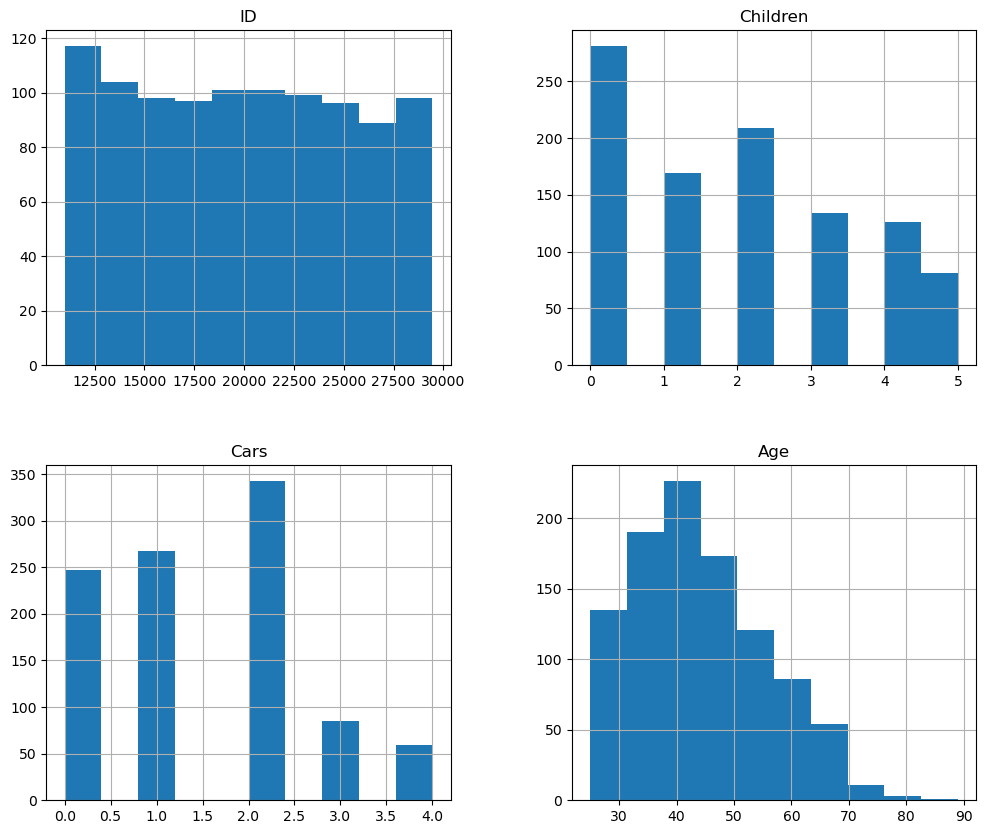

In [146]:
A.hist(figsize=(12, 10))
plt.show()

In [147]:
a= A.corr(numeric_only = True)
a

,ID,Children,Cars,Age
ID,1.000000,-0.030987,0.032816,-0.049908
Children,-0.030987,1.000000,0.263360,0.529743
Cars,0.032816,0.263360,1.000000,0.188040
Age,-0.049908,0.529743,0.188040,1.000000


<Axes: >

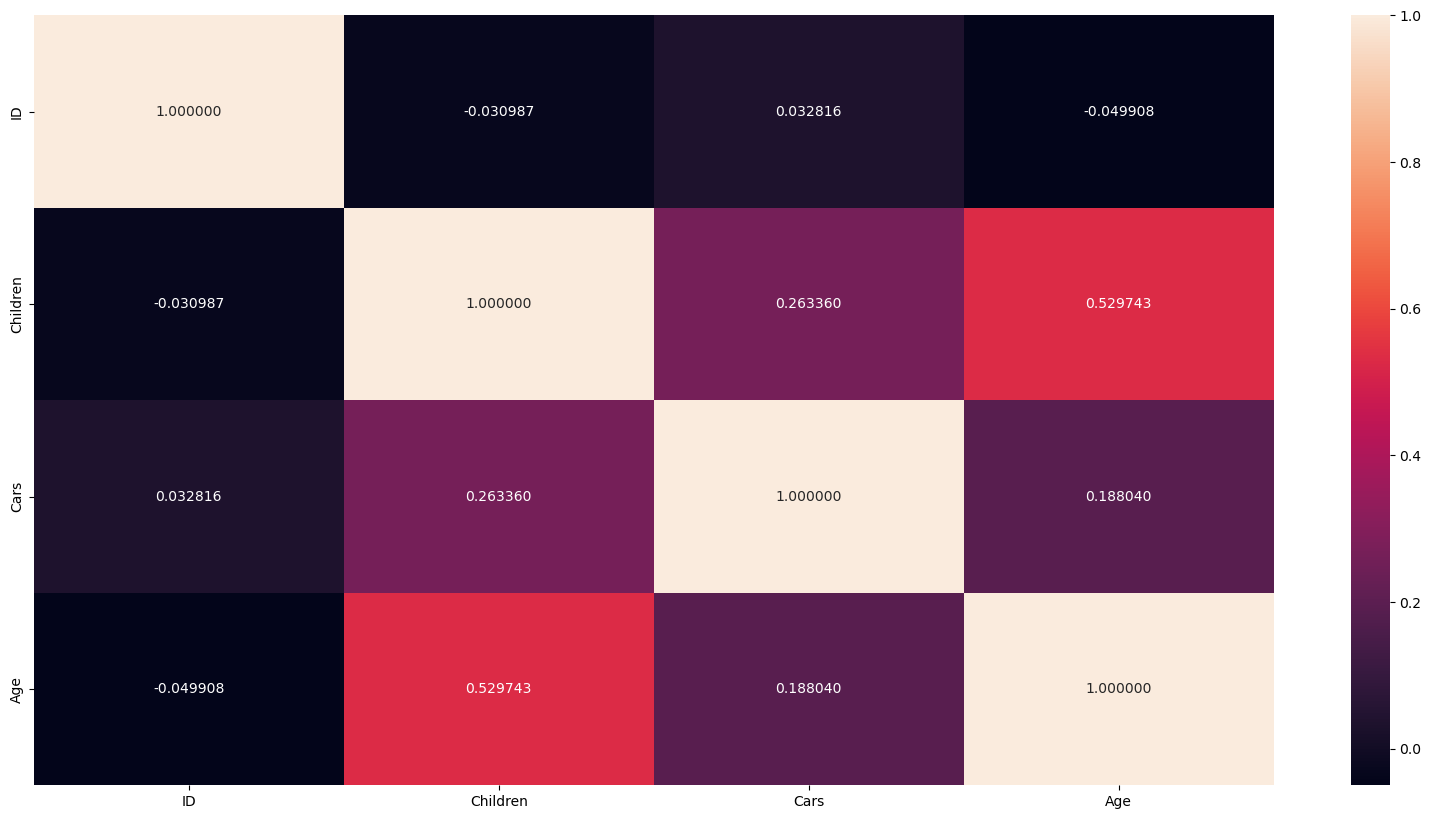

In [148]:
plt.figure(figsize =(20,10))
sns.heatmap(a,fmt = '2f', annot = True)

<Axes: ylabel='Income'>

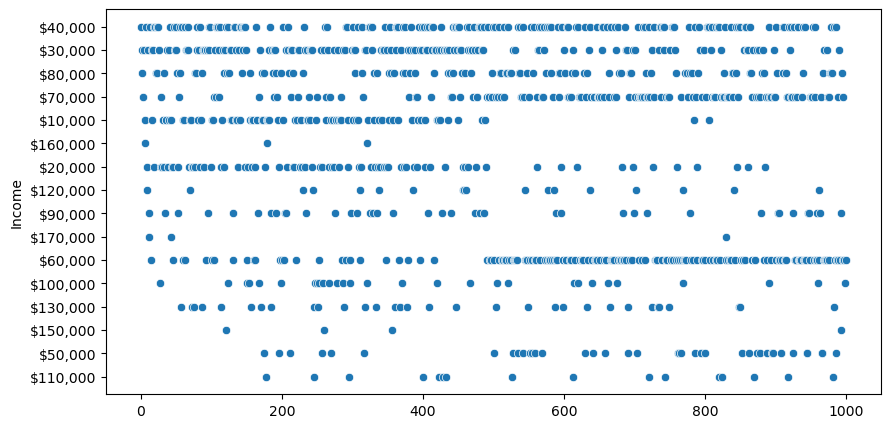

In [149]:
plt.figure(figsize = (10,5))
sns.scatterplot(A['Income'])

In [150]:
A.dtypes

ID                   int64
Martial Status      object
Gender              object
Income              object
Children             int64
Education           object
Occupation          object
Home Owner          object
Cars                 int64
Commute Distance    object
Region              object
Age                  int64
Age Brackets        object
Purchased Bike      object
dtype: object

In [151]:
A.describe()

,ID,Children,Cars,Age
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,19965.992000,1.898000,1.442000,44.163000
std,5347.333948,1.628572,1.125123,11.364488
min,11000.000000,0.000000,0.000000,25.000000
25%,15290.750000,0.000000,1.000000,35.000000
50%,19744.000000,2.000000,1.000000,43.000000
75%,24470.750000,3.000000,2.000000,52.000000
max,29447.000000,5.000000,4.000000,89.000000


In [152]:
A.isnull().sum()

ID                  0
Martial Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Age Brackets        0
Purchased Bike      0
dtype: int64

<Axes: >

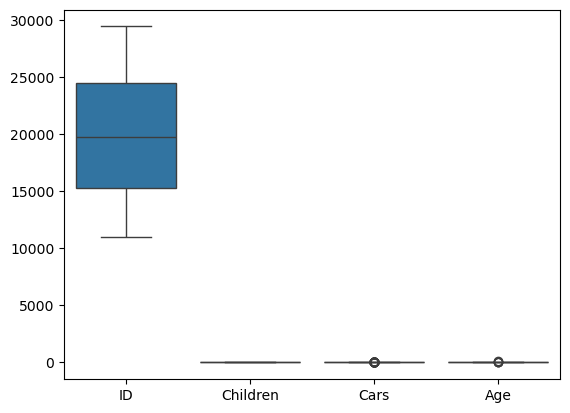

In [153]:
sns.boxplot(A)

<Axes: ylabel='Income'>

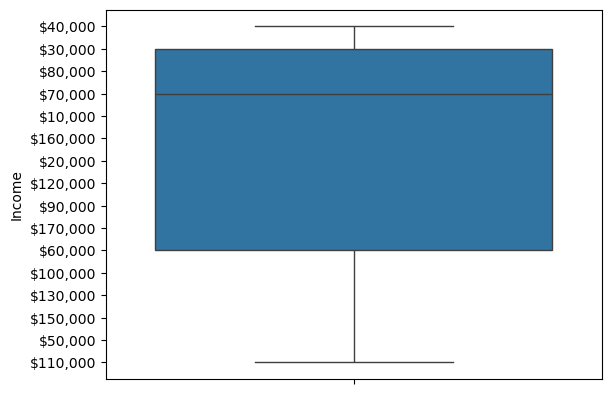

In [154]:
sns.boxplot(data=A, y = 'Income')

<Axes: ylabel='Cars'>

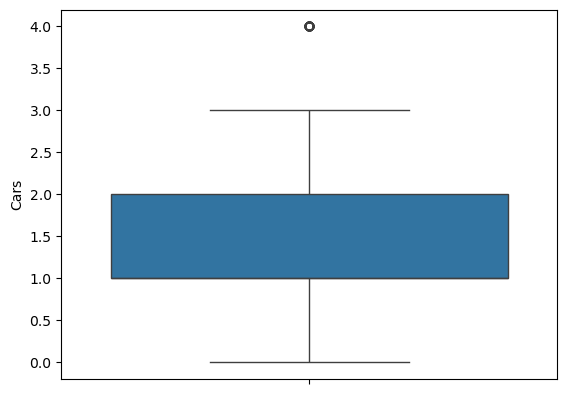

In [155]:
sns.boxplot(data=A, y = 'Cars')

<Axes: ylabel='Age'>

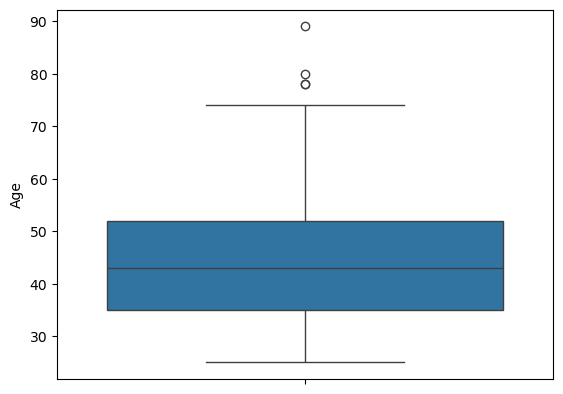

In [156]:
sns.boxplot(data=A, y = 'Age')

<Axes: ylabel='Children'>

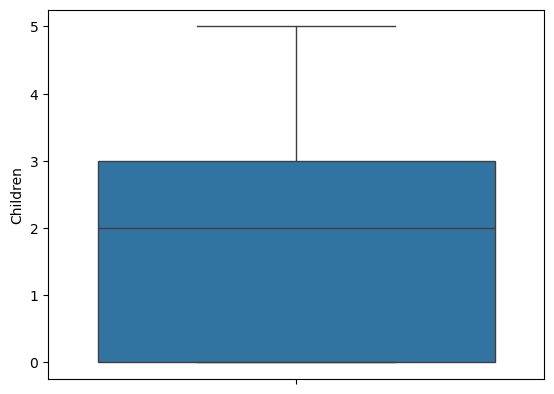

In [157]:
sns.boxplot(data=A, y = 'Children')

In [158]:
n = A[['Age', 'Cars']]   #correcting outliners 

In [159]:
for c in n.columns:
    percentile25=n[c].quantile(0.25)
    percentile75=n[c].quantile(0.75)
    iqr=percentile75-percentile25
    upper_limit=percentile75+(1.5*iqr)
    lower_limit=percentile25-(1.5*iqr)
    
    
    A=A[A[c]<upper_limit]
    A=A[A[c]>lower_limit]
    
    n=n[n[c]<upper_limit]
    n=n[n[c]>lower_limit]
    
A,n

(        ID Martial Status  Gender    Income  Children        Education  \
 0    12496        Married  Female   $40,000         1        Bachelors   
 1    24107        Married    Male   $30,000         3  Partial College   
 2    14177        Married    Male   $80,000         5  Partial College   
 3    24381         Single    Male   $70,000         0        Bachelors   
 4    25597         Single    Male   $30,000         0        Bachelors   
 ..     ...            ...     ...       ...       ...              ...   
 995  23731        Married    Male   $60,000         2      High School   
 996  28672         Single    Male   $70,000         4  Graduate Degree   
 997  11809        Married    Male   $60,000         2        Bachelors   
 998  19664         Single    Male  $100,000         3        Bachelors   
 999  12121         Single    Male   $60,000         3      High School   
 
          Occupation Home Owner  Cars    Commute Distance         Region  Age  \
 0    Skilled Man

<Axes: ylabel='Age'>

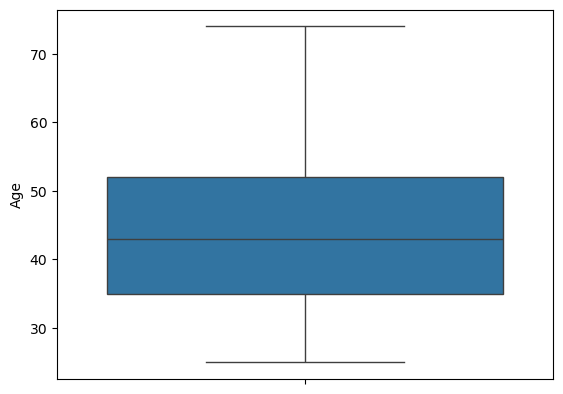

In [160]:
sns.boxplot(data=A, y = 'Age')

<Axes: ylabel='Income'>

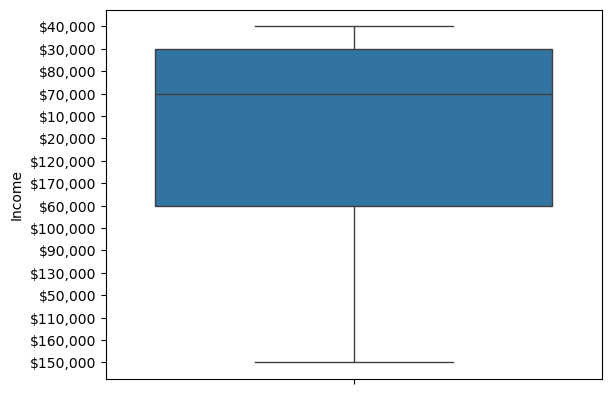

In [161]:
sns.boxplot(data=A, y = 'Income')

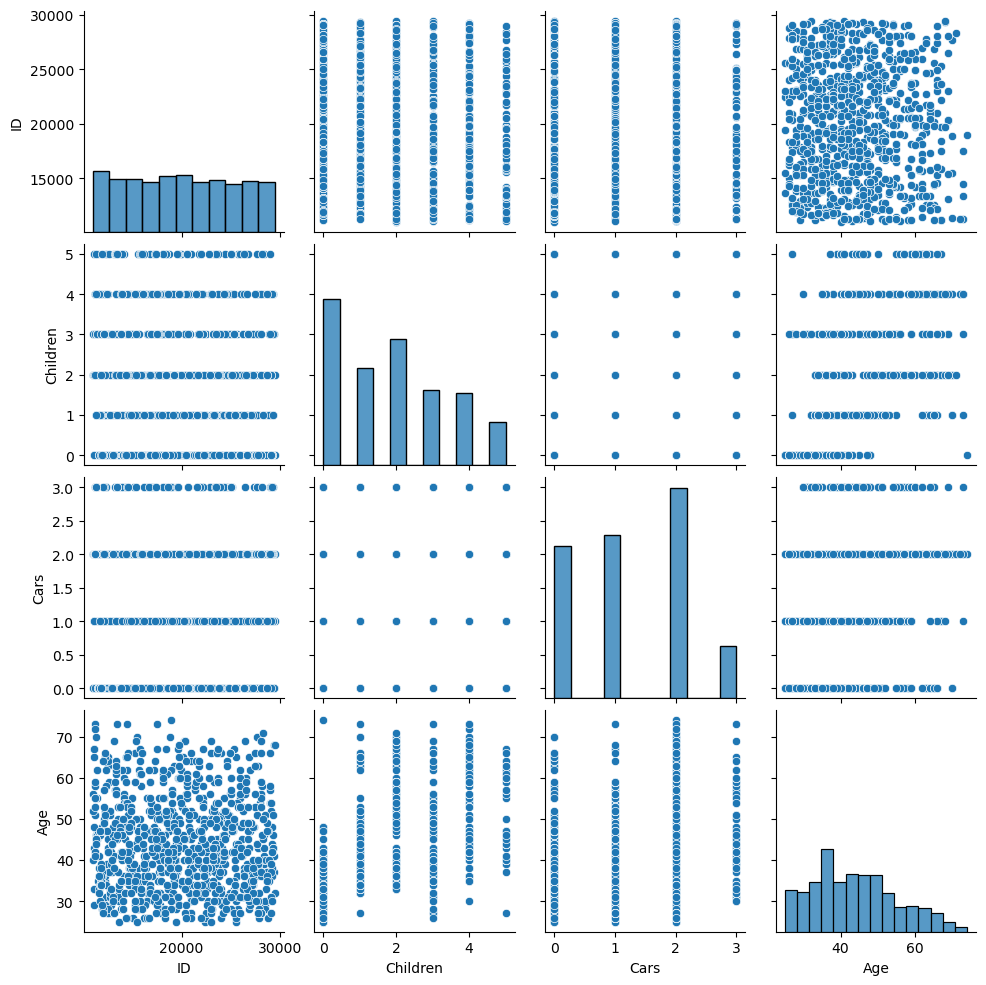

In [162]:
sns.pairplot(A)

# *DATA PREPROCESSING - Step 2*

In [163]:
A

,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike
0,12496,Married,Female,"$40,000",1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,Middle Age,No
1,24107,Married,Male,"$30,000",3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,Middle Age,No
2,14177,Married,Male,"$80,000",5,Partial College,Professional,No,2,2-5 Miles,Europe,60,Old,No
3,24381,Single,Male,"$70,000",0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Middle Age,Yes
4,25597,Single,Male,"$30,000",0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Middle Age,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,"$60,000",2,High School,Professional,Yes,2,2-5 Miles,North America,54,Middle Age,Yes
996,28672,Single,Male,"$70,000",4,Graduate Degree,Professional,Yes,0,2-5 Miles,North America,35,Middle Age,Yes
997,11809,Married,Male,"$60,000",2,Bachelors,Skilled Manual,Yes,0,0-1 Miles,North America,38,Middle Age,Yes
998,19664,Single,Male,"$100,000",3,Bachelors,Management,No,3,1-2 Miles,North America,38,Middle Age,No


In [164]:
numerical_values = ['ID', 'Income', 'Children', 'Cars', 'Age']
categorical_values = A.drop(columns=numerical_values).columns.tolist()

In [165]:
categorical_values

['Martial Status',
 'Gender',
 'Education',
 'Occupation',
 'Home Owner',
 'Commute Distance',
 'Region',
 'Age Brackets',
 'Purchased Bike']

In [166]:
numerical_values

['ID', 'Income', 'Children', 'Cars', 'Age']

In [167]:
categorical = A[categorical_values]

In [168]:
categorical

,Martial Status,Gender,Education,Occupation,Home Owner,Commute Distance,Region,Age Brackets,Purchased Bike
0,Married,Female,Bachelors,Skilled Manual,Yes,0-1 Miles,Europe,Middle Age,No
1,Married,Male,Partial College,Clerical,Yes,0-1 Miles,Europe,Middle Age,No
2,Married,Male,Partial College,Professional,No,2-5 Miles,Europe,Old,No
3,Single,Male,Bachelors,Professional,Yes,5-10 Miles,Pacific,Middle Age,Yes
4,Single,Male,Bachelors,Clerical,No,0-1 Miles,Europe,Middle Age,Yes
...,...,...,...,...,...,...,...,...,...
995,Married,Male,High School,Professional,Yes,2-5 Miles,North America,Middle Age,Yes
996,Single,Male,Graduate Degree,Professional,Yes,2-5 Miles,North America,Middle Age,Yes
997,Married,Male,Bachelors,Skilled Manual,Yes,0-1 Miles,North America,Middle Age,Yes
998,Single,Male,Bachelors,Management,No,1-2 Miles,North America,Middle Age,No


#### encoding the categorical values

In [169]:
p = pd.get_dummies(categorical, columns=categorical_values, drop_first=True)
p = p.astype(int)
p

,Martial Status_Single,Gender_Male,Education_Graduate Degree,Education_High School,Education_Partial College,Education_Partial High School,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual,Home Owner_Yes,Commute Distance_1-2 Miles,Commute Distance_2-5 Miles,Commute Distance_5-10 Miles,Commute Distance_More than 10 Miles,Region_North America,Region_Pacific,Age Brackets_Middle Age,Age Brackets_Old,Purchased Bike_Yes
0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0
1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0
3,1,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,1,0,1
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,0,1,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1
996,1,1,1,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1
997,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1
998,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0


#### encoding the numerical values

In [170]:
numerical_values

['ID', 'Income', 'Children', 'Cars', 'Age']

In [171]:
numerical_df = A[numerical_values]

In [172]:
numerical_df

,ID,Income,Children,Cars,Age
0,12496,"$40,000",1,0,42
1,24107,"$30,000",3,1,43
2,14177,"$80,000",5,2,60
3,24381,"$70,000",0,1,41
4,25597,"$30,000",0,0,36
...,...,...,...,...,...
995,23731,"$60,000",2,2,54
996,28672,"$70,000",4,0,35
997,11809,"$60,000",2,0,38
998,19664,"$100,000",3,3,38


##### using minmax scalar

In [173]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

In [176]:
A_num_mm = mm.fit_transform(numerical_df)

ValueError: could not convert string to float: '$40,000'

data = A['Income']
numerical_df = pd.DataFrame(data)

# Remove currency symbols and commas
def clean_numeric_column(column):
    return column.replace(r'[\$,]', '', regex=True).astype(float)

# Apply cleaning to relevant columns
numerical_df['Income'] = clean_numeric_column(numerical_df['Income'])

# Initialize MinMaxScaler
mm = MinMaxScaler()

# Fit and transform the data
A_num_mm = mm.fit_transform(numerical_df)

# Convert the result back to a DataFrame
A_num_mm_df = pd.DataFrame(A_num_mm, columns=numerical_df.columns)

print(A_num_mm_df)

In [141]:
q = A_num_mm
q

array([[0.1875],
       [0.125 ],
       [0.4375],
       [0.375 ],
       [0.125 ],
       [0.    ],
       [0.1875],
       [0.0625],
       [0.6875],
       [0.125 ],
       [1.    ],
       [0.1875],
       [0.3125],
       [0.    ],
       [0.125 ],
       [0.125 ],
       [0.1875],
       [0.0625],
       [0.1875],
       [0.1875],
       [0.4375],
       [0.1875],
       [0.125 ],
       [0.125 ],
       [0.5625],
       [0.375 ],
       [0.0625],
       [0.0625],
       [0.    ],
       [0.0625],
       [0.4375],
       [0.5   ],
       [0.    ],
       [0.    ],
       [0.125 ],
       [0.0625],
       [0.    ],
       [0.125 ],
       [0.1875],
       [0.    ],
       [1.    ],
       [0.0625],
       [0.0625],
       [0.3125],
       [0.1875],
       [0.125 ],
       [0.1875],
       [0.125 ],
       [0.0625],
       [0.5   ],
       [0.375 ],
       [0.4375],
       [0.1875],
       [0.1875],
       [0.3125],
       [0.    ],
       [0.    ],
       [0.1875],
       [0.3125

In [143]:
q_df = pd.DataFrame(q, columns = numerical_values)

ValueError: Shape of passed values is (937, 1), indices imply (937, 5)

In [139]:
q_df

,ID,Income,Children,Cars,Age
0,NaN,0.1875,NaN,NaN,NaN
1,NaN,0.1250,NaN,NaN,NaN
2,NaN,0.4375,NaN,NaN,NaN
3,NaN,0.3750,NaN,NaN,NaN
4,NaN,0.1250,NaN,NaN,NaN
...,...,...,...,...,...
932,NaN,0.3125,NaN,NaN,NaN
933,NaN,0.3750,NaN,NaN,NaN
934,NaN,0.3125,NaN,NaN,NaN
935,NaN,0.5625,NaN,NaN,NaN


##### using std scalar 

In [79]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [80]:
A_num_ss = ss.fit_transform(numerical_df)
print(A_num_ss)

[[-0.4620402 ]
 [-0.81430355]
 [ 0.94701323]
 [ 0.59474987]
 [-0.81430355]
 [-1.51883026]
 [-0.4620402 ]
 [-1.16656691]
 [ 2.35606665]
 [-0.81430355]
 [ 4.11738343]
 [-0.4620402 ]
 [ 0.24248652]
 [-1.51883026]
 [-0.81430355]
 [-0.81430355]
 [-0.4620402 ]
 [-1.16656691]
 [-0.4620402 ]
 [-0.4620402 ]
 [ 0.94701323]
 [-0.4620402 ]
 [-0.81430355]
 [-0.81430355]
 [ 1.65153994]
 [ 0.59474987]
 [-1.16656691]
 [-1.16656691]
 [-1.51883026]
 [-1.16656691]
 [ 0.94701323]
 [ 1.29927658]
 [-1.51883026]
 [-1.51883026]
 [-0.81430355]
 [-1.16656691]
 [-1.51883026]
 [-0.81430355]
 [-0.4620402 ]
 [-1.51883026]
 [ 4.11738343]
 [-1.16656691]
 [-1.16656691]
 [ 0.24248652]
 [-0.4620402 ]
 [-0.81430355]
 [-0.4620402 ]
 [-0.81430355]
 [-1.16656691]
 [ 1.29927658]
 [ 0.59474987]
 [ 0.94701323]
 [-0.4620402 ]
 [-0.4620402 ]
 [ 0.24248652]
 [-1.51883026]
 [-1.51883026]
 [-0.4620402 ]
 [ 0.24248652]
 [-0.81430355]
 [-0.81430355]
 [-0.4620402 ]
 [-0.81430355]
 [-1.16656691]
 [-1.51883026]
 [-1.51883026]
 [-1.16656

In [81]:
r = A_num_ss
r

array([[-0.4620402 ],
       [-0.81430355],
       [ 0.94701323],
       [ 0.59474987],
       [-0.81430355],
       [-1.51883026],
       [-0.4620402 ],
       [-1.16656691],
       [ 2.35606665],
       [-0.81430355],
       [ 4.11738343],
       [-0.4620402 ],
       [ 0.24248652],
       [-1.51883026],
       [-0.81430355],
       [-0.81430355],
       [-0.4620402 ],
       [-1.16656691],
       [-0.4620402 ],
       [-0.4620402 ],
       [ 0.94701323],
       [-0.4620402 ],
       [-0.81430355],
       [-0.81430355],
       [ 1.65153994],
       [ 0.59474987],
       [-1.16656691],
       [-1.16656691],
       [-1.51883026],
       [-1.16656691],
       [ 0.94701323],
       [ 1.29927658],
       [-1.51883026],
       [-1.51883026],
       [-0.81430355],
       [-1.16656691],
       [-1.51883026],
       [-0.81430355],
       [-0.4620402 ],
       [-1.51883026],
       [ 4.11738343],
       [-1.16656691],
       [-1.16656691],
       [ 0.24248652],
       [-0.4620402 ],
       [-0

In [86]:
r_array = np.array(r).reshape(-1, 5)
r_df = pd.DataFrame(r, columns = numerical_values)


ValueError: cannot reshape array of size 937 into shape (5)

In [88]:
r_df

,SingleColumnName
0,-0.462040
1,-0.814304
2,0.947013
3,0.594750
4,-0.814304
...,...
932,0.242487
933,0.594750
934,0.242487
935,1.651540


#### concate minmax scaler as concate_1 

In [ ]:
p

In [ ]:
q_df

In [ ]:
p.columns

In [ ]:
q_df.columns

In [ ]:
p.reset_index(drop=True, inplace=True)
q_df.reset_index(drop=True, inplace=True)

In [ ]:
p,q_df

In [ ]:
concate_1 = pd.concat([p,q_df],axis = 1, join = 'outer')

In [ ]:
concate_1

#### concate std scalar as concate_2

In [ ]:
p

In [ ]:
r_df

In [ ]:
concate_2 = pd.concat([p,r_df],axis = 1)

In [ ]:
concate_2

### splitting 

#### minmax one 

In [ ]:
concate_1

In [ ]:
minmax_dataset = concate_1.drop(columns = 'ID')

In [ ]:
minmax_dataset

In [ ]:
x1 = minmax_dataset.drop(columns = 'Purchased Bike_Yes')

In [ ]:
x1

In [ ]:
y1 = minmax_dataset['Purchased Bike_Yes']

In [ ]:
y1

 ##### splitting the data set in training and testing 

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.45,random_state=50)

### std scalar one

In [ ]:
concate_2

In [ ]:
stdscalar_dataset = concate_1.drop(columns = 'ID')

In [ ]:
stdscalar_dataset

In [ ]:
x2 = stdscalar_dataset.drop(columns = 'Purchased Bike_Yes')

In [ ]:
y2 = stdscalar_dataset['Purchased Bike_Yes']

##### splitting the std data set 

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x2_train,x2_test,y2_train,y2_test=train_test_split(x2,y2,test_size=0.6,random_state=18)

# *LOGISTIC REGRESSION - Step 3*

### minmax one

In [ ]:
x1_train,x1_test

In [ ]:
y1_train,y1_test

In [ ]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()

In [ ]:
lor.fit(x1_train, y1_train)

In [ ]:
y1_pred = lor.predict(x1_test)

#### evaluation of minmax one

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
sklearn.metrics.accuracy_score(y1_test, y1_pred)

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
sklearn.metrics.roc_auc_score(y1_test, y1_pred)

### std scaler one

In [ ]:
x2_train,x2_test

In [ ]:
y2_train,y2_test

In [ ]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()

In [ ]:
lor.fit(x2_train, y2_train)

In [ ]:
y2_pred = lor.predict(x2_test)

#### evaluation of std scalar one

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
sklearn.metrics.accuracy_score(y2_test, y2_pred)

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
sklearn.metrics.roc_auc_score(y2_test, y2_pred)